# Score-Based Generative Modeling

In [ ]:
!pip install torchmetrics[image]
from torchmetrics.utilities.imports import _MATPLOTLIB_AVAILABLE, _TORCH_FIDELITY_AVAILABLE
_TORCH_FIDELITY_AVAILABLE

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 841.5/841.5 kB 15.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.7/23.7 MB 64.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 823.6/823.6 kB 51.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.1/14.1 MB 88.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 731.7/731.7 MB 2.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 410.6/410.6 MB 3.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.6/121.6 MB 14.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.5/56.5 MB 14.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 124.2/124.2 MB 13.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 196.0/196.0 MB 4.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 166.0/166.0 MB 10.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.1/99.1 kB 16.4 MB/s eta 0:00:00
     ━━━━━━━━━━

Requirement 'torch_fidelity' met

In [ ]:
#@title Defining a time-dependent score-based model (double click to expand or collapse)

import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np

class GaussianFourierProjection(nn.Module):
  """Gaussian random features for encoding time steps."""
  def __init__(self, embed_dim, scale=30.):
    super().__init__()
    # Randomly sample weights during initialization. These weights are fixed
    # during optimization and are not trainable.
    self.W = nn.Parameter(torch.randn(embed_dim // 2) * scale, requires_grad=False)
  def forward(self, x):
    # outer product between x and W
    x_proj = x[:, None] * self.W[None, :] * 2 * np.pi
    return torch.cat([torch.sin(x_proj), torch.cos(x_proj)], dim=-1)


class Dense(nn.Module):
  """A fully connected layer that reshapes outputs to feature maps."""
  def __init__(self, input_dim, output_dim):
    super().__init__()
    self.dense = nn.Linear(input_dim, output_dim)
  def forward(self, x):
    return self.dense(x)[..., None, None]


class ScoreNet(nn.Module):
  """A time-dependent score-based model built upon U-Net architecture."""

  def __init__(self, marginal_prob_std, channels=[32, 64, 128, 256], embed_dim=256):
    """Initialize a time-dependent score-based network.

    Args:
      marginal_prob_std: A function that takes time t and gives the standard
        deviation of the perturbation kernel p_{0t}(x(t) | x(0)).
      channels: The number of channels for feature maps of each resolution.
      embed_dim: The dimensionality of Gaussian random feature embeddings.
    """
    super().__init__()
    # Gaussian random feature embedding layer for time
    self.embed = nn.Sequential(GaussianFourierProjection(embed_dim=embed_dim),
         nn.Linear(embed_dim, embed_dim))
    # Encoding layers where the resolution decreases
    self.conv1 = nn.Conv2d(1, channels[0], 3, stride=1, bias=False)
    self.dense1 = Dense(embed_dim, channels[0])
    self.gnorm1 = nn.GroupNorm(4, num_channels=channels[0])
    self.conv2 = nn.Conv2d(channels[0], channels[1], 3, stride=2, bias=False)
    self.dense2 = Dense(embed_dim, channels[1])
    self.gnorm2 = nn.GroupNorm(32, num_channels=channels[1])
    self.conv3 = nn.Conv2d(channels[1], channels[2], 3, stride=2, bias=False)
    self.dense3 = Dense(embed_dim, channels[2])
    self.gnorm3 = nn.GroupNorm(32, num_channels=channels[2])
    self.conv4 = nn.Conv2d(channels[2], channels[3], 3, stride=2, bias=False)
    self.dense4 = Dense(embed_dim, channels[3])
    self.gnorm4 = nn.GroupNorm(32, num_channels=channels[3])

    # Decoding layers where the resolution increases
    self.tconv4 = nn.ConvTranspose2d(channels[3], channels[2], 3, stride=2, bias=False)
    self.dense5 = Dense(embed_dim, channels[2])
    self.tgnorm4 = nn.GroupNorm(32, num_channels=channels[2])
    self.tconv3 = nn.ConvTranspose2d(channels[2] + channels[2], channels[1], 3, stride=2, bias=False, output_padding=1)
    self.dense6 = Dense(embed_dim, channels[1])
    self.tgnorm3 = nn.GroupNorm(32, num_channels=channels[1])
    self.tconv2 = nn.ConvTranspose2d(channels[1] + channels[1], channels[0], 3, stride=2, bias=False, output_padding=1)
    self.dense7 = Dense(embed_dim, channels[0])
    self.tgnorm2 = nn.GroupNorm(32, num_channels=channels[0])
    self.tconv1 = nn.ConvTranspose2d(channels[0] + channels[0], 1, 3, stride=1)

    # The swish activation function
    self.act = lambda x: x * torch.sigmoid(x)
    self.marginal_prob_std = marginal_prob_std

  def forward(self, x, t):
    # Obtain the Gaussian random feature embedding for t
    embed = self.act(self.embed(t))
    # Encoding path
    h1 = self.conv1(x)
    ## Incorporate information from t
    h1 += self.dense1(embed)
    ## Group normalization
    h1 = self.gnorm1(h1)
    h1 = self.act(h1)
    h2 = self.conv2(h1)
    h2 += self.dense2(embed)
    h2 = self.gnorm2(h2)
    h2 = self.act(h2)
    h3 = self.conv3(h2)
    h3 += self.dense3(embed)
    h3 = self.gnorm3(h3)
    h3 = self.act(h3)
    h4 = self.conv4(h3)
    h4 += self.dense4(embed)
    h4 = self.gnorm4(h4)
    h4 = self.act(h4)

    # Decoding path
    h = self.tconv4(h4)
    ## Skip connection from the encoding path
    h += self.dense5(embed)
    h = self.tgnorm4(h)
    h = self.act(h)
    h = self.tconv3(torch.cat([h, h3], dim=1))
    h += self.dense6(embed)
    h = self.tgnorm3(h)
    h = self.act(h)
    h = self.tconv2(torch.cat([h, h2], dim=1))
    h += self.dense7(embed)
    h = self.tgnorm2(h)
    h = self.act(h)
    h = self.tconv1(torch.cat([h, h1], dim=1))

    # Normalize output
    h = h / self.marginal_prob_std(t)[:, None, None, None]
    return h

In [ ]:
#@title Set up the Contractive sub Variance Preserving SDE
model = 'CsubVP' #@param ['CsubVP', 'subVP', 'VE', 'VP'] {'type':'string'}

device = 'cuda' #@param ['cuda', 'cpu'] {'type':'string'}

beta_max =  8.0 #@param {'type':'number'}

class CsubVPSDE():
  def __init__(self, cbeta_min=0.01, cbeta_max=8, N=1000):
    """Construct the sub-VP SDE that excels at likelihoods.

    Args:
      cbeta_min: value of beta(0)
      cbeta_max: value of beta(1)
      N: number of discretization steps
    """
    self.beta_0 = cbeta_min
    self.beta_1 = cbeta_max
    self.N = N

  @property
  def T(self):
    return 1

  def coeff(self, x, t):
    beta_t = self.beta_0 + t * (self.beta_1 - self.beta_0)
    drift =  0.5 * beta_t[:, None, None, None] * x
    explode = torch.exp(2 * self.beta_0 * t + (self.beta_1 - self.beta_0) * t ** 2) - 1
    diffusion = torch.sqrt(beta_t * explode)
    return drift, diffusion

  def marginal_prob_mean(self, x, t):
    log_mean_coeff =  0.25 * t ** 2 * (self.beta_1 - self.beta_0) + 0.5 * t * self.beta_0
    mean = torch.exp(log_mean_coeff)[:, None, None, None] * x
    return mean

  def marginal_prob_std(self, t):
    log_mean_coeff =  0.25 * t ** 2 * (self.beta_1 - self.beta_0) + 0.5 * t * self.beta_0
    std = torch.exp(2. * log_mean_coeff) - 1
    return std

  def prior_sampling(self, shape):
    return torch.randn(*shape) * (math.exp(0.5 * (self.beta_0 + self.beta_1)) - 1 )

  def prior_logp(self, z):
    shape = z.shape
    N = np.prod(shape[1:])
    return -N / 2. * np.log(2 * np.pi * (torch.exp(0.5 * (self.beta_0 + self.beta_1)) - 1 )**2) - torch.sum(z ** 2, dim=(1, 2, 3)) / (2 * (torch.exp(0.5 * (self.beta_0 + self.beta_1)) - 1 ) ** 2)

SDE = CsubVPSDE(cbeta_max = beta_max)

In [ ]:
#@title Set up the sub Variance Preserving SDE
model = 'subVP' #@param ['CsubVP', 'subVP', 'VE', 'VP'] {'type':'string'}

device = 'cuda' #@param ['cuda', 'cpu'] {'type':'string'}

beta_max =  8.0 #@param {'type':'number'}

class subVPSDE():
  def __init__(self, beta_min=0.01, beta_max=8, N=1000):
    """Construct the sub-VP SDE that excels at likelihoods.

    Args:
      cbeta_min: value of beta(0)
      cbeta_max: value of beta(1)
      N: number of discretization steps
    """
    self.beta_0 = beta_min
    self.beta_1 = beta_max
    self.N = N

  @property
  def T(self):
    return 1

  def coeff(self, x, t):
    beta_t = self.beta_0 + t * (self.beta_1 - self.beta_0)
    drift =  0.5 * beta_t[:, None, None, None] * x
    discount = 1 - torch.exp(-2 * self.beta_0 * t - (self.beta_1 - self.beta_0) * t ** 2)
    diffusion = torch.sqrt(beta_t * discount)
    return drift, diffusion

  def marginal_prob_mean(self, x, t):
    log_mean_coeff = - 0.25 * t ** 2 * (self.beta_1 - self.beta_0) - 0.5 * t * self.beta_0
    mean = torch.exp(log_mean_coeff)[:, None, None, None] * x
    return mean

  def marginal_prob_std(self, t):
    log_mean_coeff =  - 0.25 * t ** 2 * (self.beta_1 - self.beta_0) - 0.5 * t * self.beta_0
    std = 1 - torch.exp(2. * log_mean_coeff)
    return std

  def prior_sampling(self, shape):
    return torch.randn(*shape) * (1 - math.exp( - 0.5 * (self.beta_0 + self.beta_1)))

  def prior_logp(self, z):
    shape = z.shape
    N = np.prod(shape[1:])
    return -N / 2. * np.log(2 * np.pi * (1 - torch.exp(-0.5 * (self.beta_0 + self.beta_1)) )**2) - torch.sum(z ** 2, dim=(1, 2, 3)) / (2 * (1 - torch.exp(-0.5 * (self.beta_0 + self.beta_1))) ** 2)

SDE = subVPSDE(beta_max = beta_max)

In [ ]:
#@title Set up the Variance Preserving SDE
model = 'VP' #@param ['CsubVP', 'subVP', 'VE', 'VP'] {'type':'string'}

device = 'cuda' #@param ['cuda', 'cpu'] {'type':'string'}

beta_max =  8.0 #@param {'type':'number'}

class VPSDE():
  def __init__(self, beta_min=0.01, beta_max=8, N=1000):
    """Construct the sub-VP SDE that excels at likelihoods.

    Args:
      cbeta_min: value of beta(0)
      cbeta_max: value of beta(1)
      N: number of discretization steps
    """
    self.beta_0 = beta_min
    self.beta_1 = beta_max
    self.N = N

  @property
  def T(self):
    return 1

  def coeff(self, x, t):
    beta_t = self.beta_0 + t * (self.beta_1 - self.beta_0)
    drift =  0.5 * beta_t[:, None, None, None] * x
    discount = 1 - torch.exp(-2 * self.beta_0 * t - (self.beta_1 - self.beta_0) * t ** 2)
    diffusion = torch.sqrt(beta_t * discount)
    return drift, diffusion

  def marginal_prob_mean(self, x, t):
    log_mean_coeff = - 0.25 * t ** 2 * (self.beta_1 - self.beta_0) - 0.5 * t * self.beta_0
    mean = torch.exp(log_mean_coeff)[:, None, None, None] * x
    return mean

  def marginal_prob_std(self, t):
    log_mean_coeff =  - 0.25 * t ** 2 * (self.beta_1 - self.beta_0) - 0.5 * t * self.beta_0
    std = torch.sqrt(1 - torch.exp(2. * log_mean_coeff))
    return std

  def prior_sampling(self, shape):
    return torch.randn(*shape)

  def prior_logp(self, z):
    shape = z.shape
    N = np.prod(shape[1:])
    return -N / 2. * np.log(2 * np.pi) - torch.sum(z ** 2, dim=(1, 2, 3)) / 2

SDE = VPSDE(beta_max = beta_max)

In [ ]:
#@title Set up the VE SDE
model = 'VE' #@param ['CsubVP', 'subVP', 'VE', 'VP'] {'type':'string'}

device = 'cuda' #@param ['cuda', 'cpu'] {'type':'string'}

sigma =  8.0 #@param {'type':'number'}

class VESDE():
  def __init__(self, sigma=25, N=1000):
    """Construct the sub-VP SDE that excels at likelihoods.

    Args:
      cbeta_min: value of beta(0)
      cbeta_max: value of beta(1)
      N: number of discretization steps
    """
    self.sigma = sigma
    self.N = N

  @property
  def T(self):
    return 1

  def coeff(self, x, t):
    drift =  0
    diffusion = torch.tensor(sigma**t, device=device)
    return drift, diffusion

  def marginal_prob_mean(self, x, t):
    mean = x
    return mean

  def marginal_prob_std(self, t):
    t = torch.tensor(t, device=device)
    return torch.sqrt((sigma**(2 * t) - 1.) / 2. / np.log(sigma))

  def prior_sampling(self, shape):
    return torch.randn(*shape) * torch.sqrt((sigma**(2 * t) - 1.) / 2. / np.log(sigma))

SDE = VESDE(sigma = sigma)

In [ ]:
def loss_fn(model, x, sde, eps=1e-5):
  """The loss function for training score-based generative models.

  Args:
    model: A PyTorch model instance that represents a
      time-dependent score-based model.
    x: A mini-batch of training data.
    marginal_prob_std: A function that gives the standard deviation of
      the perturbation kernel.
    eps: A tolerance value for numerical stability.
  """
  random_t = torch.rand(x.shape[0], device=x.device) * (1. - eps) + eps
  z = torch.randn_like(x)
  mean = sde.marginal_prob_mean(x, random_t)
  std = sde.marginal_prob_std(random_t)
  perturbed_x = mean + z * std[:, None, None, None]
  score = model(perturbed_x, random_t)
  loss = torch.mean(torch.sum((score * std[:, None, None, None] + z)**2, dim=(1,2,3)))
  return loss

In [ ]:
#@title Training (double click to expand or collapse)

import torch
# import functools
from torch.optim import Adam
from torch.utils.data import DataLoader
import torchvision.transforms as transforms
from torchvision.datasets import MNIST
from tqdm.notebook import trange, tqdm


score_model = torch.nn.DataParallel(ScoreNet(marginal_prob_std=SDE.marginal_prob_std))
score_model = score_model.to(device)

n_epochs =   2000 #@param {'type':'integer'}
## size of a mini-batch
batch_size =  128 #@param {'type':'integer'}
## learning rate
lr=5e-4 #@param {'type':'number'}

dataset = MNIST('.', train=True, transform=transforms.ToTensor(), download=True)
data_loader = DataLoader(dataset, batch_size=batch_size, shuffle=True, num_workers=4)

optimizer = Adam(score_model.parameters(), lr=lr)
# tqdm_epoch = tqdm.notebook.trange(n_epochs)
tqdm_epoch = trange(n_epochs)
for epoch in tqdm_epoch:
  avg_loss = 0.
  num_items = 0
  for x,y in data_loader:
    x = x.to(device)
    loss = loss_fn(score_model, x, SDE)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    avg_loss += loss.item() * x.shape[0]
    num_items += x.shape[0]
  # Print the averaged training loss so far.
  tqdm_epoch.set_description('Average Loss: {:5f}'.format(avg_loss / num_items))
  # Update the checkpoint after each epoch of training.
  torch.save(score_model.state_dict(), 'ckpt.pth')

100%|██████████| 9912422/9912422 [00:00<00:00, 297107308.71it/s]

Extracting ./MNIST/raw/train-images-idx3-ubyte.gz to ./MNIST/raw


100%|██████████| 28881/28881 [00:00<00:00, 27789789.82it/s]


Extracting ./MNIST/raw/train-labels-idx1-ubyte.gz to ./MNIST/raw



100%|██████████| 1648877/1648877 [00:00<00:00, 112025453.90it/s]

Extracting ./MNIST/raw/t10k-images-idx3-ubyte.gz to ./MNIST/raw




100%|██████████| 4542/4542 [00:00<00:00, 5054531.38it/s]


Extracting ./MNIST/raw/t10k-labels-idx1-ubyte.gz to ./MNIST/raw



  0%|          | 0/2000 [00:00<?, ?it/s]

<ipython-input-3-b3c3148c992a>:34: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  t = torch.tensor(t, device=device)


In [ ]:
original_data = dataset.data.unsqueeze(1)
original_data_3c = torch.cat([original_data, original_data, original_data], dim=1)
original_data_3c.shape

torch.Size([60000, 3, 28, 28])

In [ ]:
#@title Define the Euler-Maruyama sampler (double click to expand or collapse)

## The number of sampling steps.
num_steps =  1000#@param {'type':'integer'}
def Euler_Maruyama_sampler(score_model,
                           sde,
                           batch_size=64,
                           num_steps=num_steps,
                           device='cuda',
                           eps=1e-3):
  """Generate samples from score-based models with the Euler-Maruyama solver.

  Args:
    score_model: A PyTorch model that represents the time-dependent score-based model.
    marginal_prob_std: A function that gives the standard deviation of
      the perturbation kernel.
    diffusion_coeff: A function that gives the diffusion coefficient of the SDE.
    batch_size: The number of samplers to generate by calling this function once.
    num_steps: The number of sampling steps.
      Equivalent to the number of discretized time steps.
    device: 'cuda' for running on GPUs, and 'cpu' for running on CPUs.
    eps: The smallest time step for numerical stability.

  Returns:
    Samples.
  """
  t = torch.ones(batch_size, device=device)
  init_x = torch.randn(batch_size, 1, 28, 28, device=device) \
    * sde.marginal_prob_std(t)[:, None, None, None]
  time_steps = torch.linspace(1., eps, num_steps, device=device)
  step_size = time_steps[0] - time_steps[1]
  x = init_x
  with torch.no_grad():
    for time_step in tqdm(time_steps):
      batch_time_step = torch.ones(batch_size, device=device) * time_step
      f,g = sde.coeff(x, batch_time_step)
      mean_x = x + (-f + (g**2)[:, None, None, None] * score_model(x, batch_time_step)) * step_size
      x = mean_x + torch.sqrt(step_size) * g[:, None, None, None] * torch.randn_like(x)
  # Do not include any noise in the last sampling step.
  return mean_x

## Sampling with Predictor-Corrector Methods

Aside from generic numerical SDE solvers, we can leverage special properties of our reverse-time SDE for better solutions. Since we have an estimate of the score of $p_t(\mathbf{x}(t))$ via the score-based model, i.e., $s_\theta(\mathbf{x}, t) \approx \nabla_{\mathbf{x}(t)} \log p_t(\mathbf{x}(t))$, we can leverage score-based MCMC approaches, such as Langevin MCMC, to correct the solution obtained by numerical SDE solvers.

Score-based MCMC approaches can produce samples from a distribution $p(\mathbf{x})$ once its score $\nabla_\mathbf{x} \log p(\mathbf{x})$ is known. For example, Langevin MCMC operates by running the following iteration rule for $i=1,2,\cdots, N$:
\begin{align*}
\mathbf{x}_{i+1} = \mathbf{x}_{i} + \epsilon \nabla_\mathbf{x} \log p(\mathbf{x}_i) + \sqrt{2\epsilon} \mathbf{z}_i,
\end{align*}
where $\mathbf{z}_i \sim \mathcal{N}(\mathbf{0}, \mathbf{I})$, $\epsilon > 0$ is the step size, and $\mathbf{x}_1$ is initialized from any prior distribution $\pi(\mathbf{x}_1)$. When $N\to\infty$ and $\epsilon \to 0$, the final value $\mathbf{x}_{N+1}$ becomes a sample from $p(\mathbf{x})$ under some regularity conditions. Therefore, given $s_\theta(\mathbf{x}, t) \approx \nabla_\mathbf{x} \log p_t(\mathbf{x})$, we can get an approximate sample from $p_t(\mathbf{x})$ by running several steps of Langevin MCMC, replacing $\nabla_\mathbf{x} \log p_t(\mathbf{x})$ with $s_\theta(\mathbf{x}, t)$ in the iteration rule.

Predictor-Corrector samplers combine both numerical solvers for the reverse-time SDE and the Langevin MCMC approach. In particular, we first apply one step of numerical SDE solver to obtain $\mathbf{x}_{t-\Delta t}$ from $\mathbf{x}_t$, which is called the "predictor" step. Next, we apply several steps of Langevin MCMC to refine $\mathbf{x}_t$, such that $\mathbf{x}_t$ becomes a more accurate sample from $p_{t-\Delta t}(\mathbf{x})$. This is the "corrector" step as the MCMC helps reduce the error of the numerical SDE solver.

In [ ]:
#@title Define the Predictor-Corrector sampler (double click to expand or collapse)

signal_to_noise_ratio = 0.16 #@param {'type':'number'}

## The number of sampling steps.
num_steps =  10000#@param {'type':'integer'}
def pc_sampler(score_model,
               sde,
               batch_size=64,
               num_steps=num_steps,
               snr=signal_to_noise_ratio,
               device='cuda',
               eps=1e-3):
  """Generate samples from score-based models with Predictor-Corrector method.

  Args:
    score_model: A PyTorch model that represents the time-dependent score-based model.
    marginal_prob_std: A function that gives the standard deviation
      of the perturbation kernel.
    diffusion_coeff: A function that gives the diffusion coefficient
      of the SDE.
    batch_size: The number of samplers to generate by calling this function once.
    num_steps: The number of sampling steps.
      Equivalent to the number of discretized time steps.
    device: 'cuda' for running on GPUs, and 'cpu' for running on CPUs.
    eps: The smallest time step for numerical stability.

  Returns:
    Samples.
  """
  t = torch.ones(batch_size, device=device)
  init_x = torch.randn(batch_size, 1, 28, 28, device=device) * sde.marginal_prob_std(t)[:, None, None, None]
  time_steps = np.linspace(1., eps, num_steps)
  step_size = time_steps[0] - time_steps[1]
  x = init_x
  with torch.no_grad():
    for time_step in tqdm(time_steps):
      batch_time_step = torch.ones(batch_size, device=device) * time_step
      # Corrector step (Langevin MCMC)
      grad = score_model(x, batch_time_step)
      grad_norm = torch.norm(grad.reshape(grad.shape[0], -1), dim=-1).mean()
      noise_norm = np.sqrt(np.prod(x.shape[1:]))
      langevin_step_size = 2 * (snr * noise_norm / grad_norm)**2
      x = x + langevin_step_size * grad + torch.sqrt(2 * langevin_step_size) * torch.randn_like(x)

      # Predictor step (Euler-Maruyama)
      f , g = sde.coeff(x, batch_time_step)
      x_mean = x + ((g**2)[:, None, None, None] * score_model(x, batch_time_step) -f ) * step_size
      x = x_mean + torch.sqrt(g**2 * step_size)[:, None, None, None] * torch.randn_like(x)

    # The last step does not include any noise
    return x_mean

In [ ]:
#@title Sampling (double click to expand or collapse)

from torchvision.utils import make_grid

## Load the pre-trained checkpoint from disk.
device = 'cuda' #@param ['cuda', 'cpu'] {'type':'string'}
ckpt = torch.load('ckpt.pth', map_location=device)
score_model.load_state_dict(ckpt)

sample_batch_size = 25 #@param {'type':'integer'}
sampler = pc_sampler #@param ['Euler_Maruyama_sampler', 'pc_sampler'] {'type': 'raw'}

## Generate samples using the specified sampler.
samples = sampler(score_model,
                  SDE,
                  sample_batch_size,
                  device=device)

## Sample visualization.
samples = samples.clamp(0.0, 1.0)
%matplotlib inline
import matplotlib.pyplot as plt
sample_grid = make_grid(samples, nrow=5)

<ipython-input-3-b3c3148c992a>:34: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  t = torch.tensor(t, device=device)


  0%|          | 0/10000 [00:00<?, ?it/s]

<ipython-input-3-b3c3148c992a>:26: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  diffusion = torch.tensor(sigma**t, device=device)


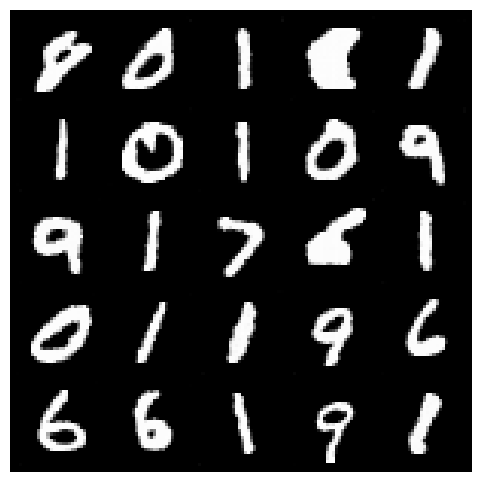

In [ ]:
#@title Results for CsubVP
plt.figure(figsize=(6,6))
plt.axis('off')
plt.imshow(sample_grid.permute(1, 2, 0).cpu(), vmin=0., vmax=1.)
plt.savefig("MNIST_CsubVP.png")
plt.show()

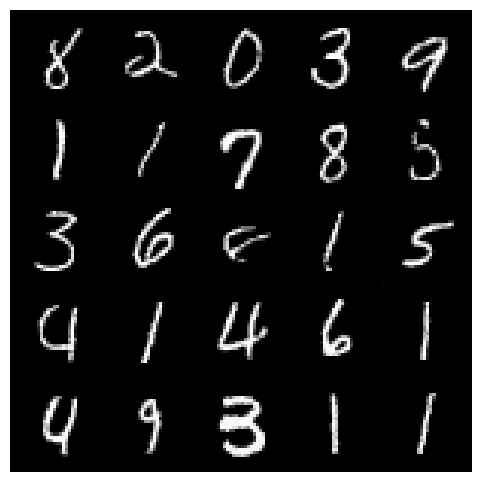

In [ ]:
# subVP
plt.figure(figsize=(6,6))
plt.axis('off')
plt.imshow(sample_grid.permute(1, 2, 0).cpu(), vmin=0., vmax=1.)
plt.savefig("MNIST_subVP.png")
plt.show()

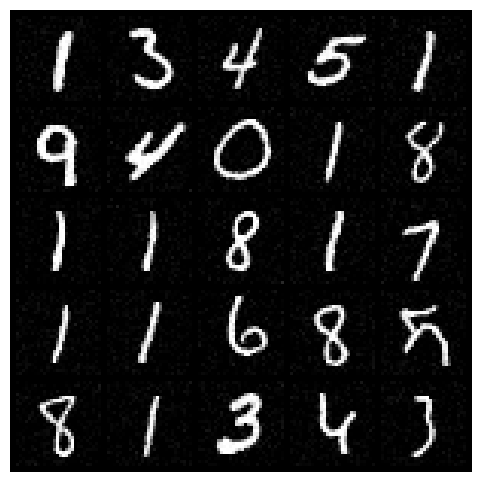

In [ ]:
# VE
plt.figure(figsize=(6,6))
plt.axis('off')
plt.imshow(sample_grid.permute(1, 2, 0).cpu(), vmin=0., vmax=1.)
plt.savefig("MNIST_VE.png")
plt.show()

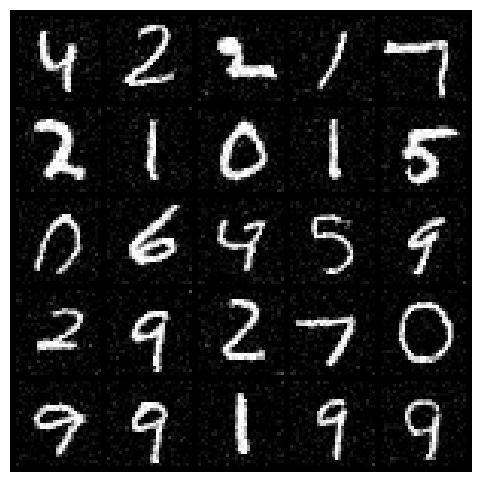

In [ ]:
# VP
plt.figure(figsize=(6,6))
plt.axis('off')
plt.imshow(sample_grid.permute(1, 2, 0).cpu(), vmin=0., vmax=1.)
plt.savefig("MNIST_VP.png")
plt.show()

In [ ]:
samples.shape

torch.Size([25, 1, 28, 28])

In [ ]:
#@title Compute FIDs (double click to expand or collapse)

from torchvision.utils import make_grid

## Load the pre-trained checkpoint from disk.
device = 'cuda' #@param ['cuda', 'cpu'] {'type':'string'}
ckpt = torch.load('ckpt.pth', map_location=device)
score_model.load_state_dict(ckpt)

sample_batch_size = 2000 #@param {'type':'integer'}
sampler = pc_sampler #@param ['Euler_Maruyama_sampler', 'pc_sampler'] {'type': 'raw'}

## Generate samples using the specified sampler.
samples = sampler(score_model,
                  SDE,
                  sample_batch_size,
                  device=device)
samples = samples.clamp(0.0, 1.0)
samples_cat = torch.cat([samples, samples, samples], dim=1)
samples_cat.shape

<ipython-input-3-b3c3148c992a>:34: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  t = torch.tensor(t, device=device)


  0%|          | 0/10000 [00:00<?, ?it/s]

<ipython-input-3-b3c3148c992a>:26: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  diffusion = torch.tensor(sigma**t, device=device)


torch.Size([2000, 3, 28, 28])

In [ ]:
#@title CsubVP
from torchmetrics.image.fid import FrechetInceptionDistance
fid = FrechetInceptionDistance(feature=64,normalize = True)
imgs_dist1 = original_data_3c[:2000]/255.
imgs_dist2 = samples_cat.cpu()
fid.update(imgs_dist1, real=True)
fid.update(imgs_dist2, real=False)
fid.compute()

tensor(0.0260)

In [ ]:
from torchmetrics.image.fid import FrechetInceptionDistance
fid = FrechetInceptionDistance(feature=64,normalize = True)
imgs_dist1 = original_data_3c[:2000]/255.
imgs_dist2 = samples_cat.cpu()
fid.update(imgs_dist1, real=True)
fid.update(imgs_dist2, real=False)
fid.compute()

tensor(0.0938)

In [ ]:
#@title subVP
from torchmetrics.image.fid import FrechetInceptionDistance
fid = FrechetInceptionDistance(feature=64,normalize = True)
imgs_dist1 = original_data_3c[:2000]/255.
imgs_dist2 = samples_cat.cpu()
fid.update(imgs_dist1, real=True)
fid.update(imgs_dist2, real=False)
fid.compute()

tensor(0.5266)

In [ ]:
#@title VE
from torchmetrics.image.fid import FrechetInceptionDistance
fid = FrechetInceptionDistance(feature=64,normalize = True)
imgs_dist1 = original_data_3c[:2000]/255.
imgs_dist2 = samples_cat.cpu()
fid.update(imgs_dist1, real=True)
fid.update(imgs_dist2, real=False)
fid.compute()

tensor(0.0168)

In [ ]:
from torchmetrics.image.fid import FrechetInceptionDistance
fid = FrechetInceptionDistance(feature=64,normalize = True)
imgs_dist1 = original_data_3c[:2000]/255.
imgs_dist2 = samples_cat.cpu()
fid.update(imgs_dist1, real=True)
fid.update(imgs_dist2, real=False)
fid.compute()

Downloading: "https://github.com/toshas/torch-fidelity/releases/download/v0.2.0/weights-inception-2015-12-05-6726825d.pth" to /root/.cache/torch/hub/checkpoints/weights-inception-2015-12-05-6726825d.pth
100%|██████████| 91.2M/91.2M [00:00<00:00, 467MB/s]


tensor(0.2183)

In [ ]:
#@title VP
from torchmetrics.image.fid import FrechetInceptionDistance
fid = FrechetInceptionDistance(feature=64,normalize = True)
imgs_dist1 = original_data_3c[:2000]/255.
imgs_dist2 = samples_cat.cpu()
fid.update(imgs_dist1, real=True)
fid.update(imgs_dist2, real=False)
fid.compute()

tensor(0.7882)